In [1]:
import torch
import torch.nn as nn
import torchvision
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms

from tqdm import tqdm
import random

from utils_week9to11 import train, test

from model.resnet import resnet18

In [2]:
batch_size = 128
device = torch.device('cuda') if torch.cuda.is_available() else 'cpu'

## CIFAR-10 Data

In [3]:
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2471, 0.2435, 0.2616)),])

train_data = torchvision.datasets.CIFAR10(root='data/', train=True, transform=transform, download=True)
train_loader = DataLoader(dataset=train_data, batch_size=batch_size, shuffle=True)
print('Clean train data is prepared.')

test_data = torchvision.datasets.CIFAR10(root='data/', train=False, transform=transform, download=True)
test_loader = DataLoader(dataset=test_data, batch_size=batch_size, shuffle=True)
print('Clean test data is prepared.')

/home/godke/Works/AISystemSecurity/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Clean train data is prepared.
Clean test data is prepared.


## ResNet-18 Model

In [4]:
model = resnet18()

model.load_state_dict(torch.load('./model/resnet18.pt'))
model = model.to(device)

test_acc = test(model, test_loader, device)
print(test_acc)

93.07


## Clean Label Attack

In [5]:
%load_ext autoreload
%autoreload 2
from poison_frog import get_features, select_targets_and_bases, create_poisoned_dataset, finetune_model
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import random

# 1. Feature Extraction
print("Extracting features from clean model...")
train_loader_unshuffled = DataLoader(dataset=train_data, batch_size=batch_size, shuffle=False)
test_loader_unshuffled = DataLoader(dataset=test_data, batch_size=batch_size, shuffle=False)

train_features, train_labels, train_images = get_features(model, train_loader_unshuffled, device)
test_features, test_labels, test_images = get_features(model, test_loader_unshuffled, device)


Extracting features from clean model...


In [6]:
# 2. Target and Base Selection
print("Selecting targets and bases...")
target_indices, base_indices = select_targets_and_bases(
    train_features, train_labels, train_images,
    test_features, test_labels, test_images
)


Selecting targets and bases...


In [7]:
# 3. Create Poisoned Dataset
print("Creating poisoned dataset...")
# Optimization hyperparams (lr, beta) have been adjusted in poison_frog.py to be more aggressive
poisoned_train_data, poisons, bases, targets = create_poisoned_dataset(
    train_data, target_indices, base_indices, test_images, test_features, model, device
)


Creating poisoned dataset...
Optimizing poison samples...


100%|██████████| 100/100 [02:46<00:00,  1.66s/it]


In [15]:
# To ensure the poisoned samples are not washed out by 50,000 clean samples during fine-tuning,
# we increase the ratio of poisoned samples in the training subset.
all_indices = set(range(len(poisoned_train_data)))
clean_indices = list(all_indices - set(base_indices))
selected_clean_indices = random.sample(clean_indices, 5000)  # subset of clean samples
# 差不多1比1的比例，不然模型要么过于干净，要么过于中毒
subset_indices = base_indices * 50 + selected_clean_indices

subset_train_data = Subset(poisoned_train_data, subset_indices)
poisoned_train_loader = DataLoader(
    dataset=subset_train_data, batch_size=batch_size, shuffle=True
)

In [16]:
# 4. Save confidences of target samples on CLEAN model
# Reload the clean model to ensure no contamination from fine-tuning
model = resnet18()
model.load_state_dict(torch.load('./model/resnet18.pt'))
model = model.to(device)
model.eval()
clean_confidences = []
with torch.no_grad():
    for target_idx in target_indices:
        target_img = test_images[target_idx].unsqueeze(0).to(device)
        output = model(target_img)
        prob = F.softmax(output, dim=1)[0]
        true_class = test_labels[target_idx].item()
        target_class = (true_class + 1) % 10
        clean_confidences.append(prob[target_class].item())


In [17]:
# 5. Fine-tune Model on Poisoned Dataset
print("Fine-tuning model on poisoned dataset...")
poisoned_model = finetune_model(model, poisoned_train_loader, epochs=10, lr=0.01, device=device)

Fine-tuning model on poisoned dataset...


Fine-tuning Epoch 10: 100%|██████████| 79/79 [00:00<00:00, 80.08it/s]


In [18]:
# 6. Evaluation (ASR and Clean ACC)
poisoned_model.eval()
poisoned_confidences = []
success_count = 0

with torch.no_grad():
    for target_idx in target_indices:
        target_img = test_images[target_idx].unsqueeze(0).to(device)
        output = poisoned_model(target_img)
        prob = F.softmax(output, dim=1)[0]
        
        true_class = test_labels[target_idx].item()
        target_class = (true_class + 1) % 10
        
        poisoned_confidences.append(prob[target_class].item())
        
        pred_class = torch.argmax(output, dim=1).item()
        if pred_class == target_class:
            success_count += 1

asr = success_count / len(target_indices) * 100
print(f"Attack Success Rate (ASR) on target samples: {asr:.2f}%")

# Test clean accuracy of the poisoned model to ensure it hasn't degraded
clean_acc = test(poisoned_model, test_loader, device)
print(f"Clean Test Accuracy of poisoned model: {clean_acc:.2f}%")


Attack Success Rate (ASR) on target samples: 38.00%
Clean Test Accuracy of poisoned model: 63.71%


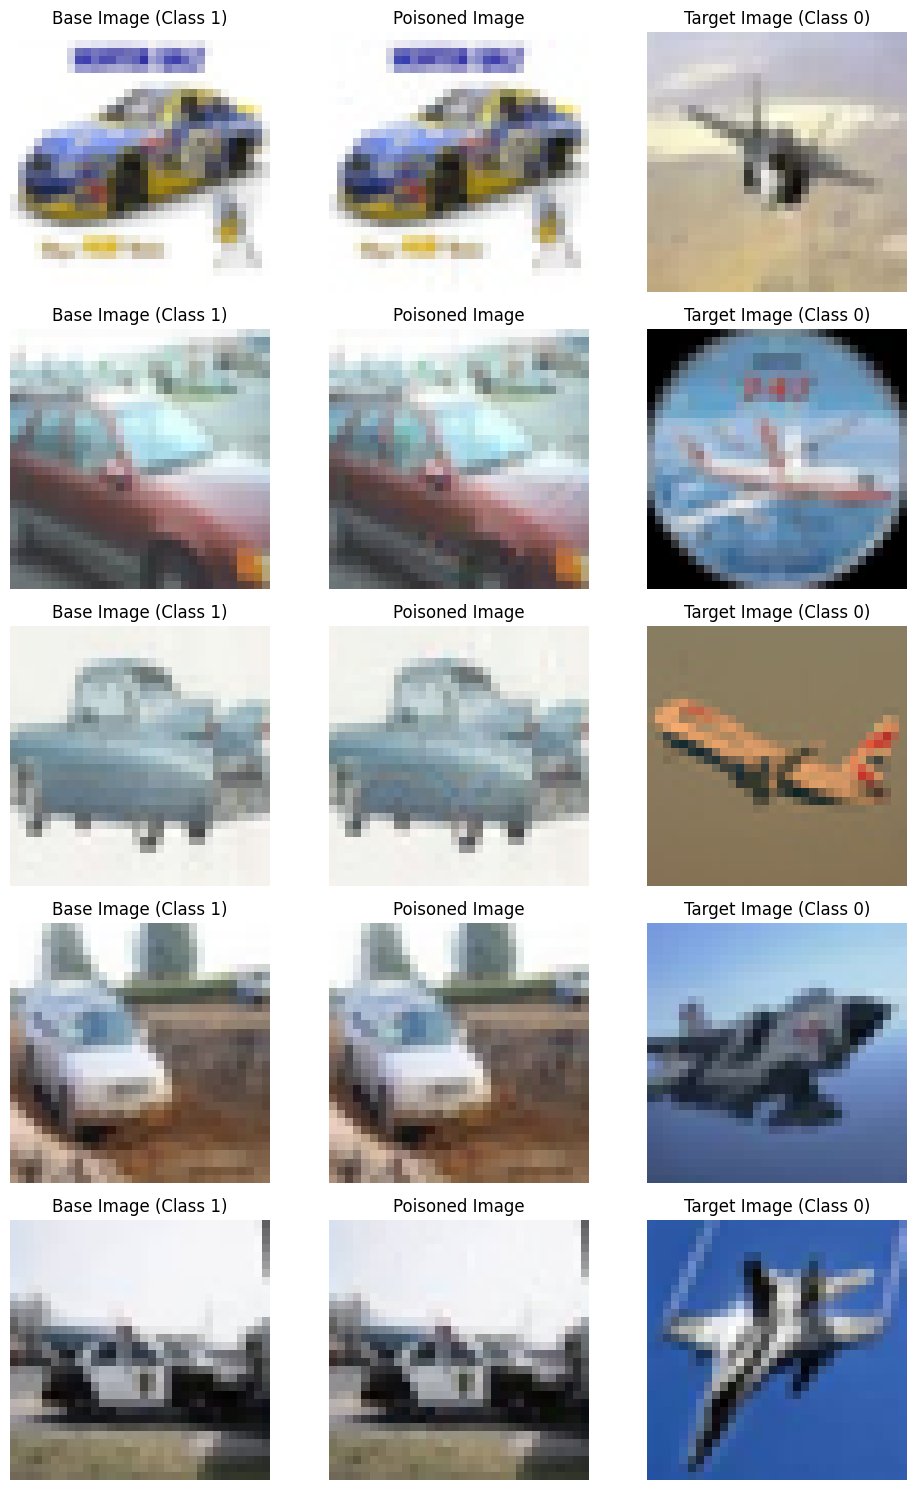

In [19]:
# 7. Visualization: Images
import matplotlib.pyplot as plt
import numpy as np

# Inverse normalize function for visualization
def imshow(img, title=None):
    img = img.cpu()
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    std = torch.tensor([0.2471, 0.2435, 0.2616]).view(3, 1, 1)
    img = img * std + mean
    img = img.clamp(0, 1)
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    if title:
        plt.title(title)
    plt.axis('off')

# Plot a few examples
num_show = 5
fig = plt.figure(figsize=(10, num_show * 3))
for i in range(num_show):
    plt.subplot(num_show, 3, i * 3 + 1)
    imshow(bases[i], title=f"Base Image (Class {(test_labels[target_indices[i]].item()+1)%10})")
    
    plt.subplot(num_show, 3, i * 3 + 2)
    imshow(poisons[i], title="Poisoned Image")
    
    plt.subplot(num_show, 3, i * 3 + 3)
    imshow(targets[i], title=f"Target Image (Class {test_labels[target_indices[i]].item()})")

plt.tight_layout()
plt.show()


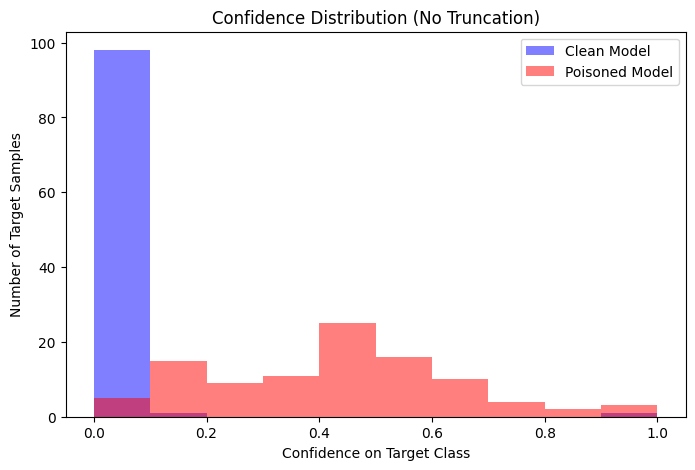

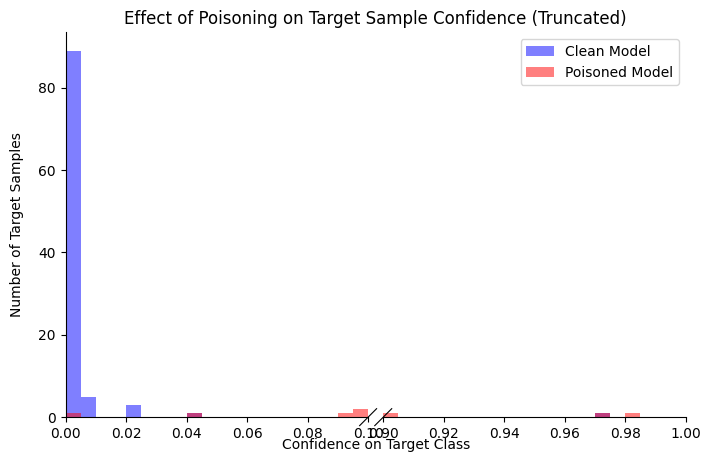

In [20]:
# 8. Visualization: Confidences
from brokenaxes import brokenaxes

# Figure A: Standard Histogram (Interval = 0.1)
plt.figure(figsize=(8, 5))
plt.hist(clean_confidences, bins=10, range=(0, 1), color="b", alpha=0.5, label="Clean Model")
plt.hist(poisoned_confidences, bins=10, range=(0, 1), color="r", alpha=0.5, label="Poisoned Model")
plt.xlabel("Confidence on Target Class")
plt.ylabel("Number of Target Samples")
plt.title("Confidence Distribution (No Truncation)")
plt.legend()
plt.show()

# Figure B: Brokenaxes Histogram
fig = plt.figure(figsize=(8, 5))
bax = brokenaxes(xlims=((0, 0.1), (0.9, 1)), wspace=0.05)

num_bins = 200 
bax.hist(clean_confidences, bins=num_bins, range=(0, 1), color="b", alpha=0.5, label="Clean Model")
bax.hist(poisoned_confidences, bins=num_bins, range=(0, 1), color="r", alpha=0.5, label="Poisoned Model")

bax.set_xlabel("Confidence on Target Class")
bax.set_ylabel("Number of Target Samples")
bax.legend()
plt.title("Effect of Poisoning on Target Sample Confidence (Truncated)")
plt.show()
